In [21]:

# Importing all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")
print(f"   Pandas   : {pd.__version__}")
print(f"   Seaborn  : {sns.__version__}")

✅ All libraries imported successfully!
   Pandas   : 3.0.0
   Seaborn  : 0.13.2


In [22]:

# Creating an organised output folder to save all plots
output_folder = "visual_report_output"
os.makedirs(output_folder, exist_ok=True)

print(f"Output folder ready: '{output_folder}/'")
print("   All plots will be saved here as PNG files.")

Output folder ready: 'visual_report_output/'
   All plots will be saved here as PNG files.


In [23]:
# ─────────────────────────────────────────────
# Loading the Titanic dataset directly from seaborn
# No download needed — seaborn has it built-in
# ─────────────────────────────────────────────
df = sns.load_dataset('titanic')

print("Titanic Dataset Loaded Successfully!")
print(f"\n->Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n->Columns       :\n{df.columns.tolist()}")
print(f"\n->Data Types    :\n{df.dtypes}")
print(f"\n->Missing Values :\n{df.isnull().sum()}")
print(f"\n->Basic Stats   :\n{df.describe()}")

Titanic Dataset Loaded Successfully!

->Shape         : 891 rows × 15 columns

->Columns       :
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

->Data Types    :
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

->Missing Values :
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

->Basic Stats   :
         survived      pcla

In [24]:

# Identifying numeric and categorical columns separately
# This helps us know which plots to apply where

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("->Numeric Columns     :", numeric_cols)
print("->Categorical Columns :", categorical_cols)
print(f"\nTotal Numeric    : {len(numeric_cols)}")
print(f"Total Categorical: {len(categorical_cols)}")

->Numeric Columns     : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
->Categorical Columns : ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Total Numeric    : 6
Total Categorical: 9


C:\Users\X280\AppData\Local\Temp\ipykernel_3364\2966233153.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


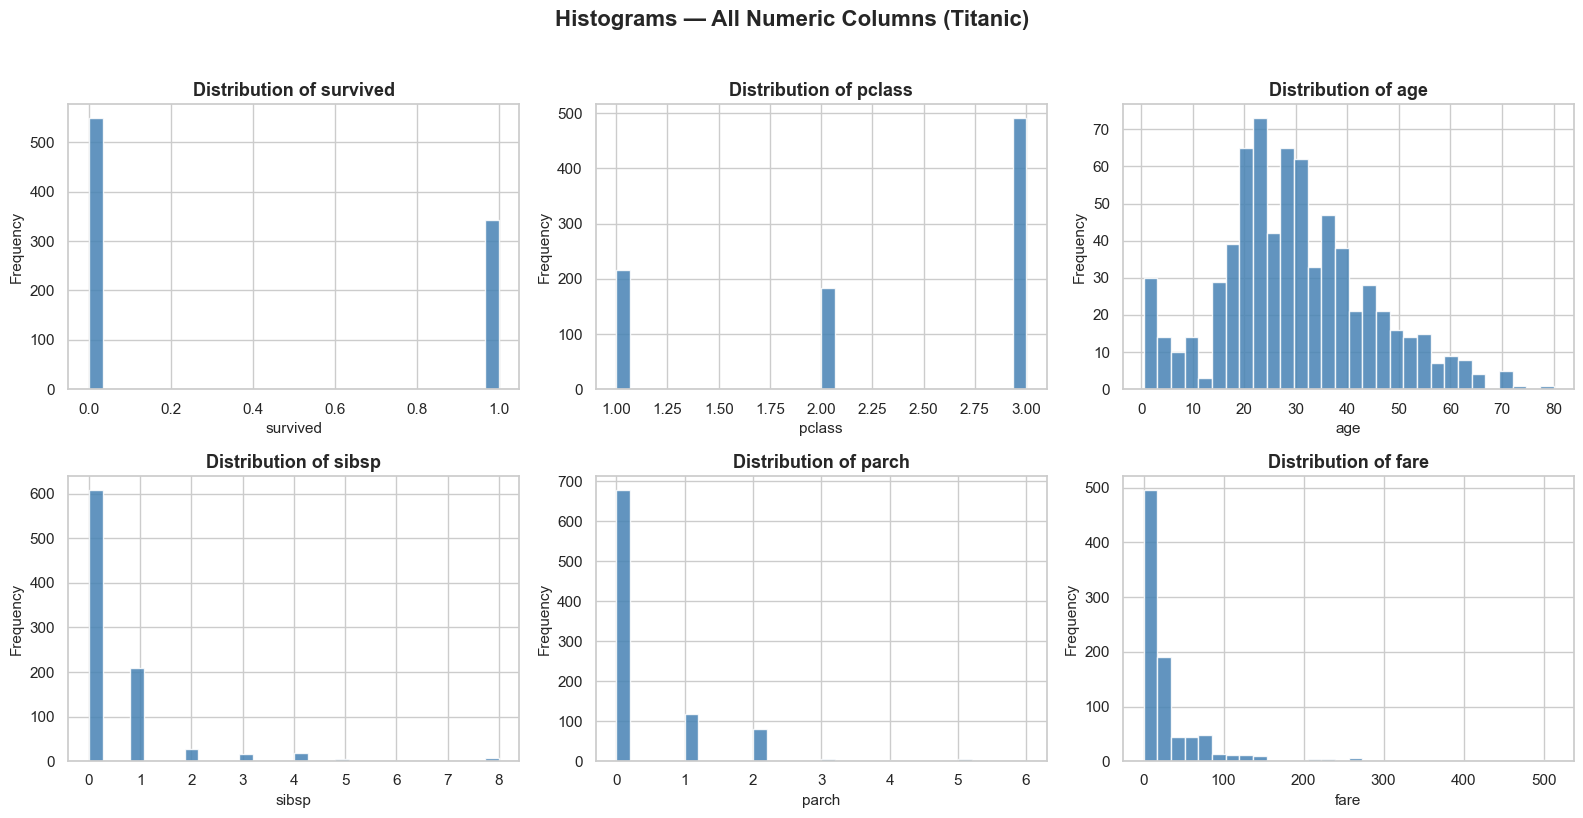

Saved: visual_report_output\01_histograms_numeric_columns.png


In [25]:

# PLOT 1: Histogram for each numeric column
# Histogram shows the distribution/frequency of values
n_cols = 3  # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()  # flatten to easily loop over

for i, col in enumerate(numeric_cols):
    axes[i].hist(
        df[col].dropna(),        # drop NaN values before plotting
        bins=30,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)

# Hide any extra empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms — All Numeric Columns (Titanic)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the plot as PNG
save_path = os.path.join(output_folder, '01_histograms_numeric_columns.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

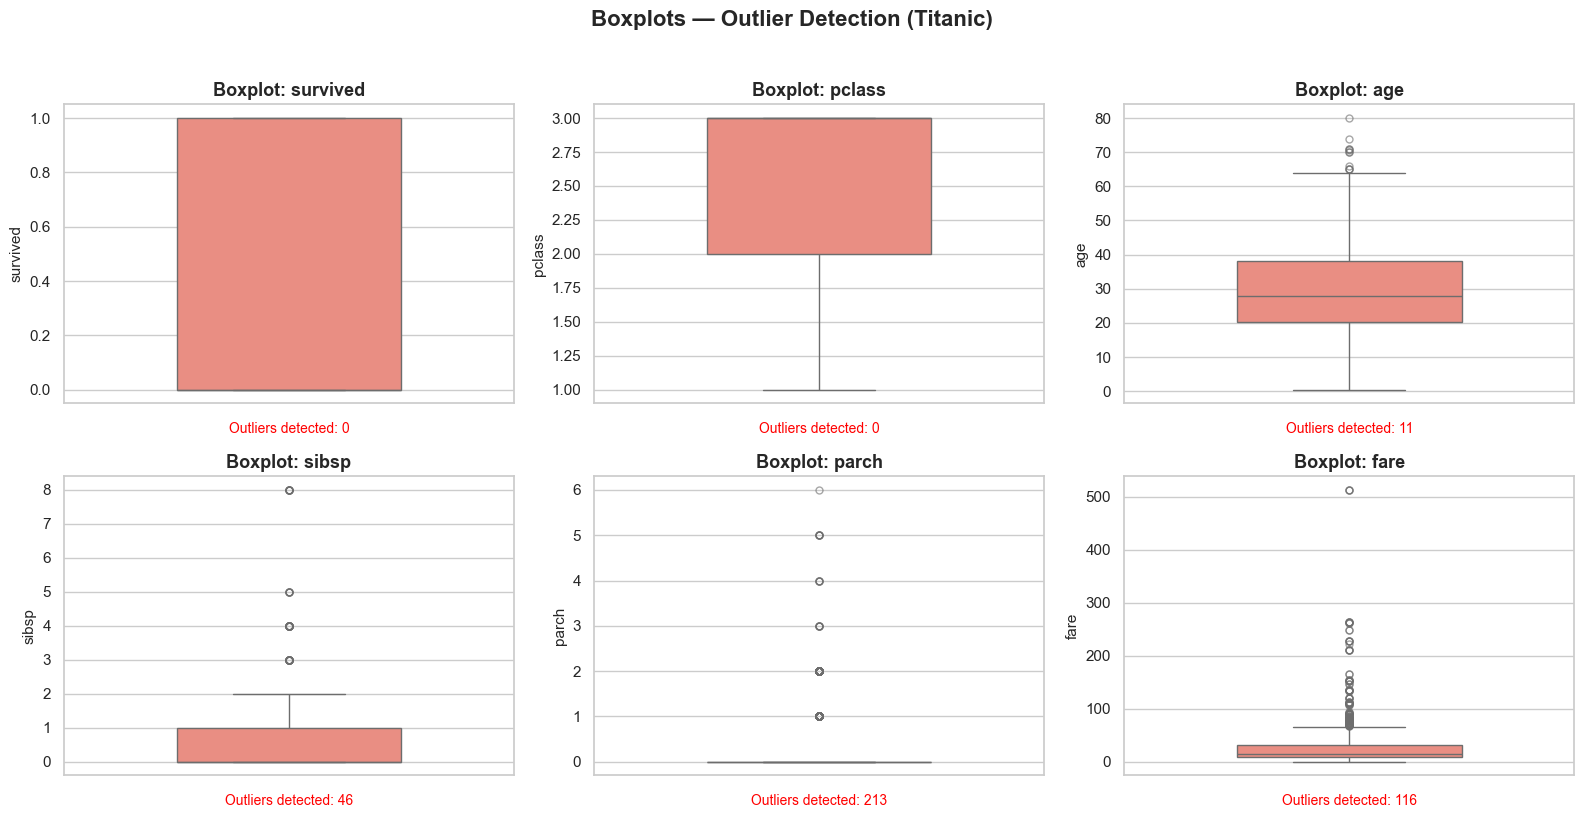

Saved: visual_report_output\02_boxplots_outlier_detection.png


In [26]:

# PLOT 2: Boxplot for each numeric column
# Boxplot shows median, spread, and outliers clearly
# Dots outside the whiskers = outliers

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df[col].dropna(),
        ax=axes[i],
        color='salmon',
        width=0.5,
        flierprops=dict(marker='o', color='red', markersize=5, alpha=0.6)
        # flierprops — styling for outlier dots
    )
    axes[i].set_title(f'Boxplot: {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=11)

    # Calculate and annotate outlier count
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    axes[i].set_xlabel(f'Outliers detected: {len(outliers)}', fontsize=10, color='red')

# Hide extra axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection (Titanic)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

save_path = os.path.join(output_folder, '02_boxplots_outlier_detection.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

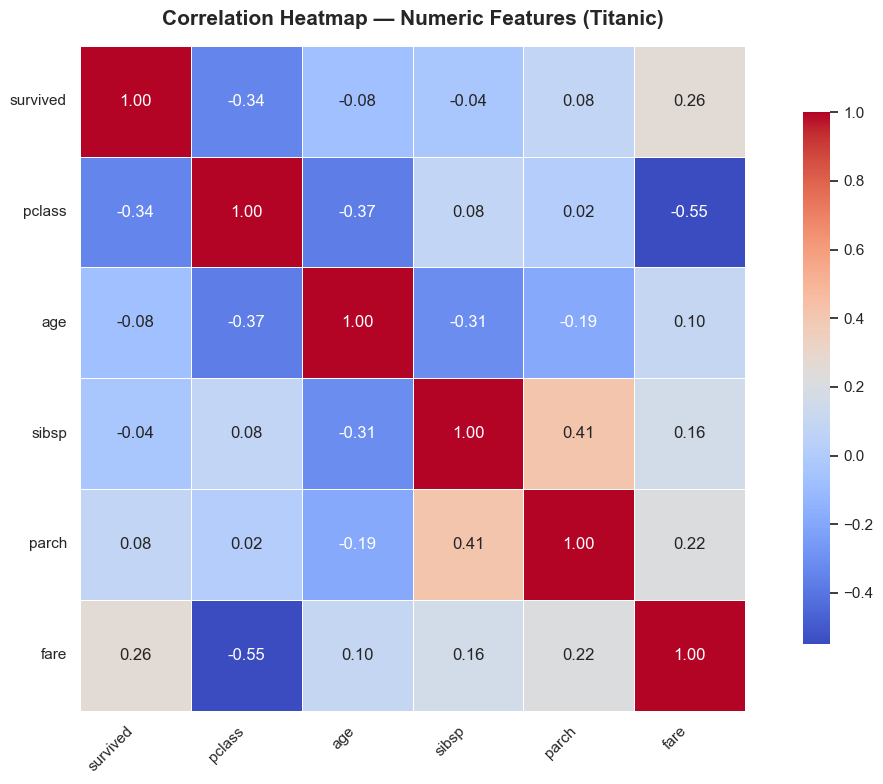

 Saved: visual_report_output\03_heatmap_correlation_matrix.png


In [27]:

# PLOT 3: Heatmap of Correlation Matrix
# Shows how strongly each numeric column relates to others
# +1 = perfect positive, -1 = perfect negative, 0 = no relation

# Compute correlation matrix (only numeric columns)
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values inside cells
    fmt='.2f',            # round to 2 decimal places
    cmap='coolwarm',      # red = positive, blue = negative correlation
    linewidths=0.5,
    linecolor='white',
    square=True,          # make cells square shaped
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap — Numeric Features (Titanic)',
          fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

save_path = os.path.join(output_folder, '03_heatmap_correlation_matrix.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f" Saved: {save_path}")

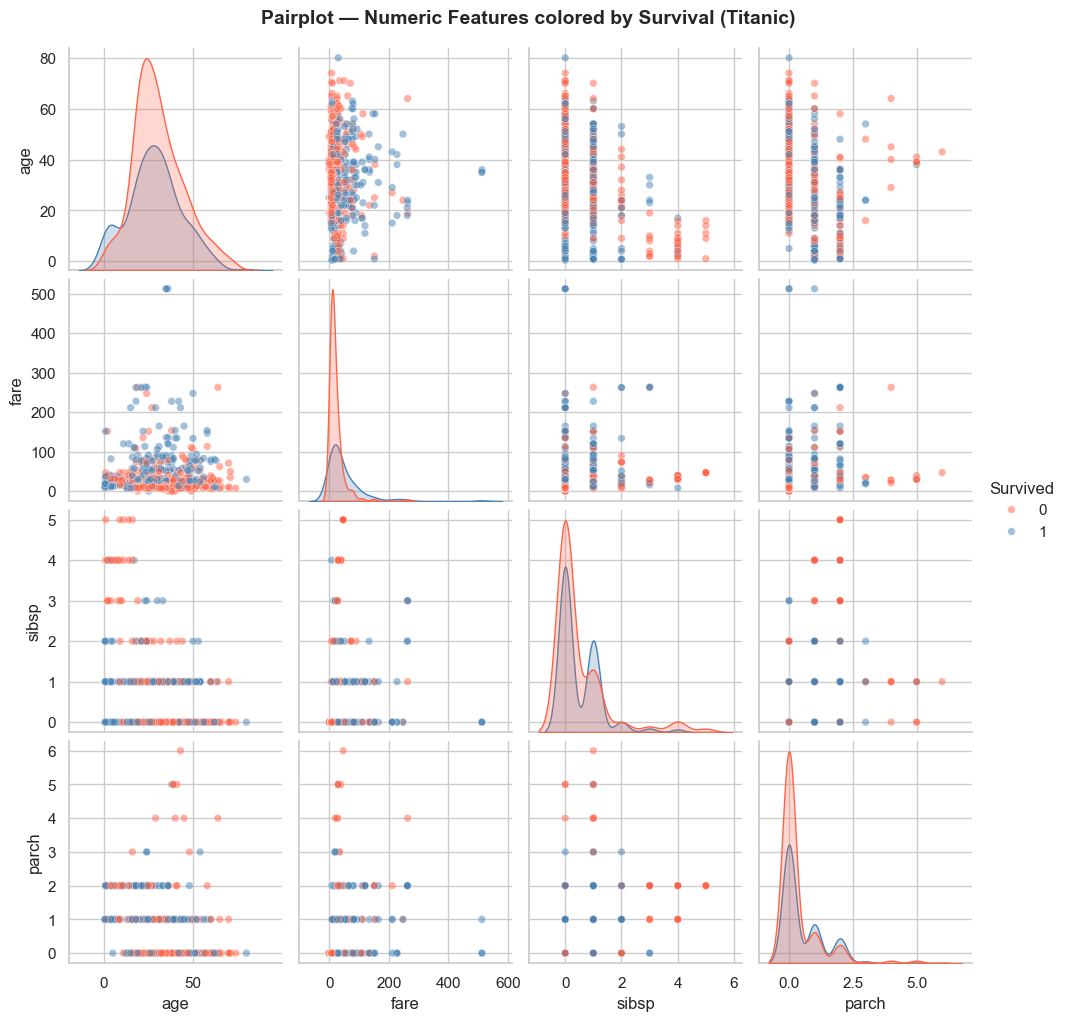

Saved: visual_report_output\04_pairplot_numeric_features.png


In [28]:

# PLOT 4: Pairplot for all numeric features
# Shows scatter plot between every pair of numeric columns
# Diagonal shows distribution of each column itself
# Hue = 'survived' to see class separation

# Select key numeric columns + survival as hue
pairplot_cols = ['age', 'fare', 'sibsp', 'parch', 'survived']
df_pair = df[pairplot_cols].dropna()

pair_grid = sns.pairplot(
    df_pair,
    hue='survived',              # color by survival (0 = No, 1 = Yes)
    palette={0: 'tomato', 1: 'steelblue'},
    diag_kind='kde',             # kernel density plot on diagonal
    plot_kws={'alpha': 0.5, 's': 30},
    height=2.5
)

pair_grid.figure.suptitle(
    'Pairplot — Numeric Features colored by Survival (Titanic)',
    fontsize=14, fontweight='bold', y=1.02
)

# Add legend labels manually
handles = pair_grid.legend.legend_handles
pair_grid.legend.set_title('Survived')
for handle, label in zip(handles, ['No (0)', 'Yes (1)']):
    handle.set_label(label)

save_path = os.path.join(output_folder, '04_pairplot_numeric_features.png')
pair_grid.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

Categorical columns for countplot: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


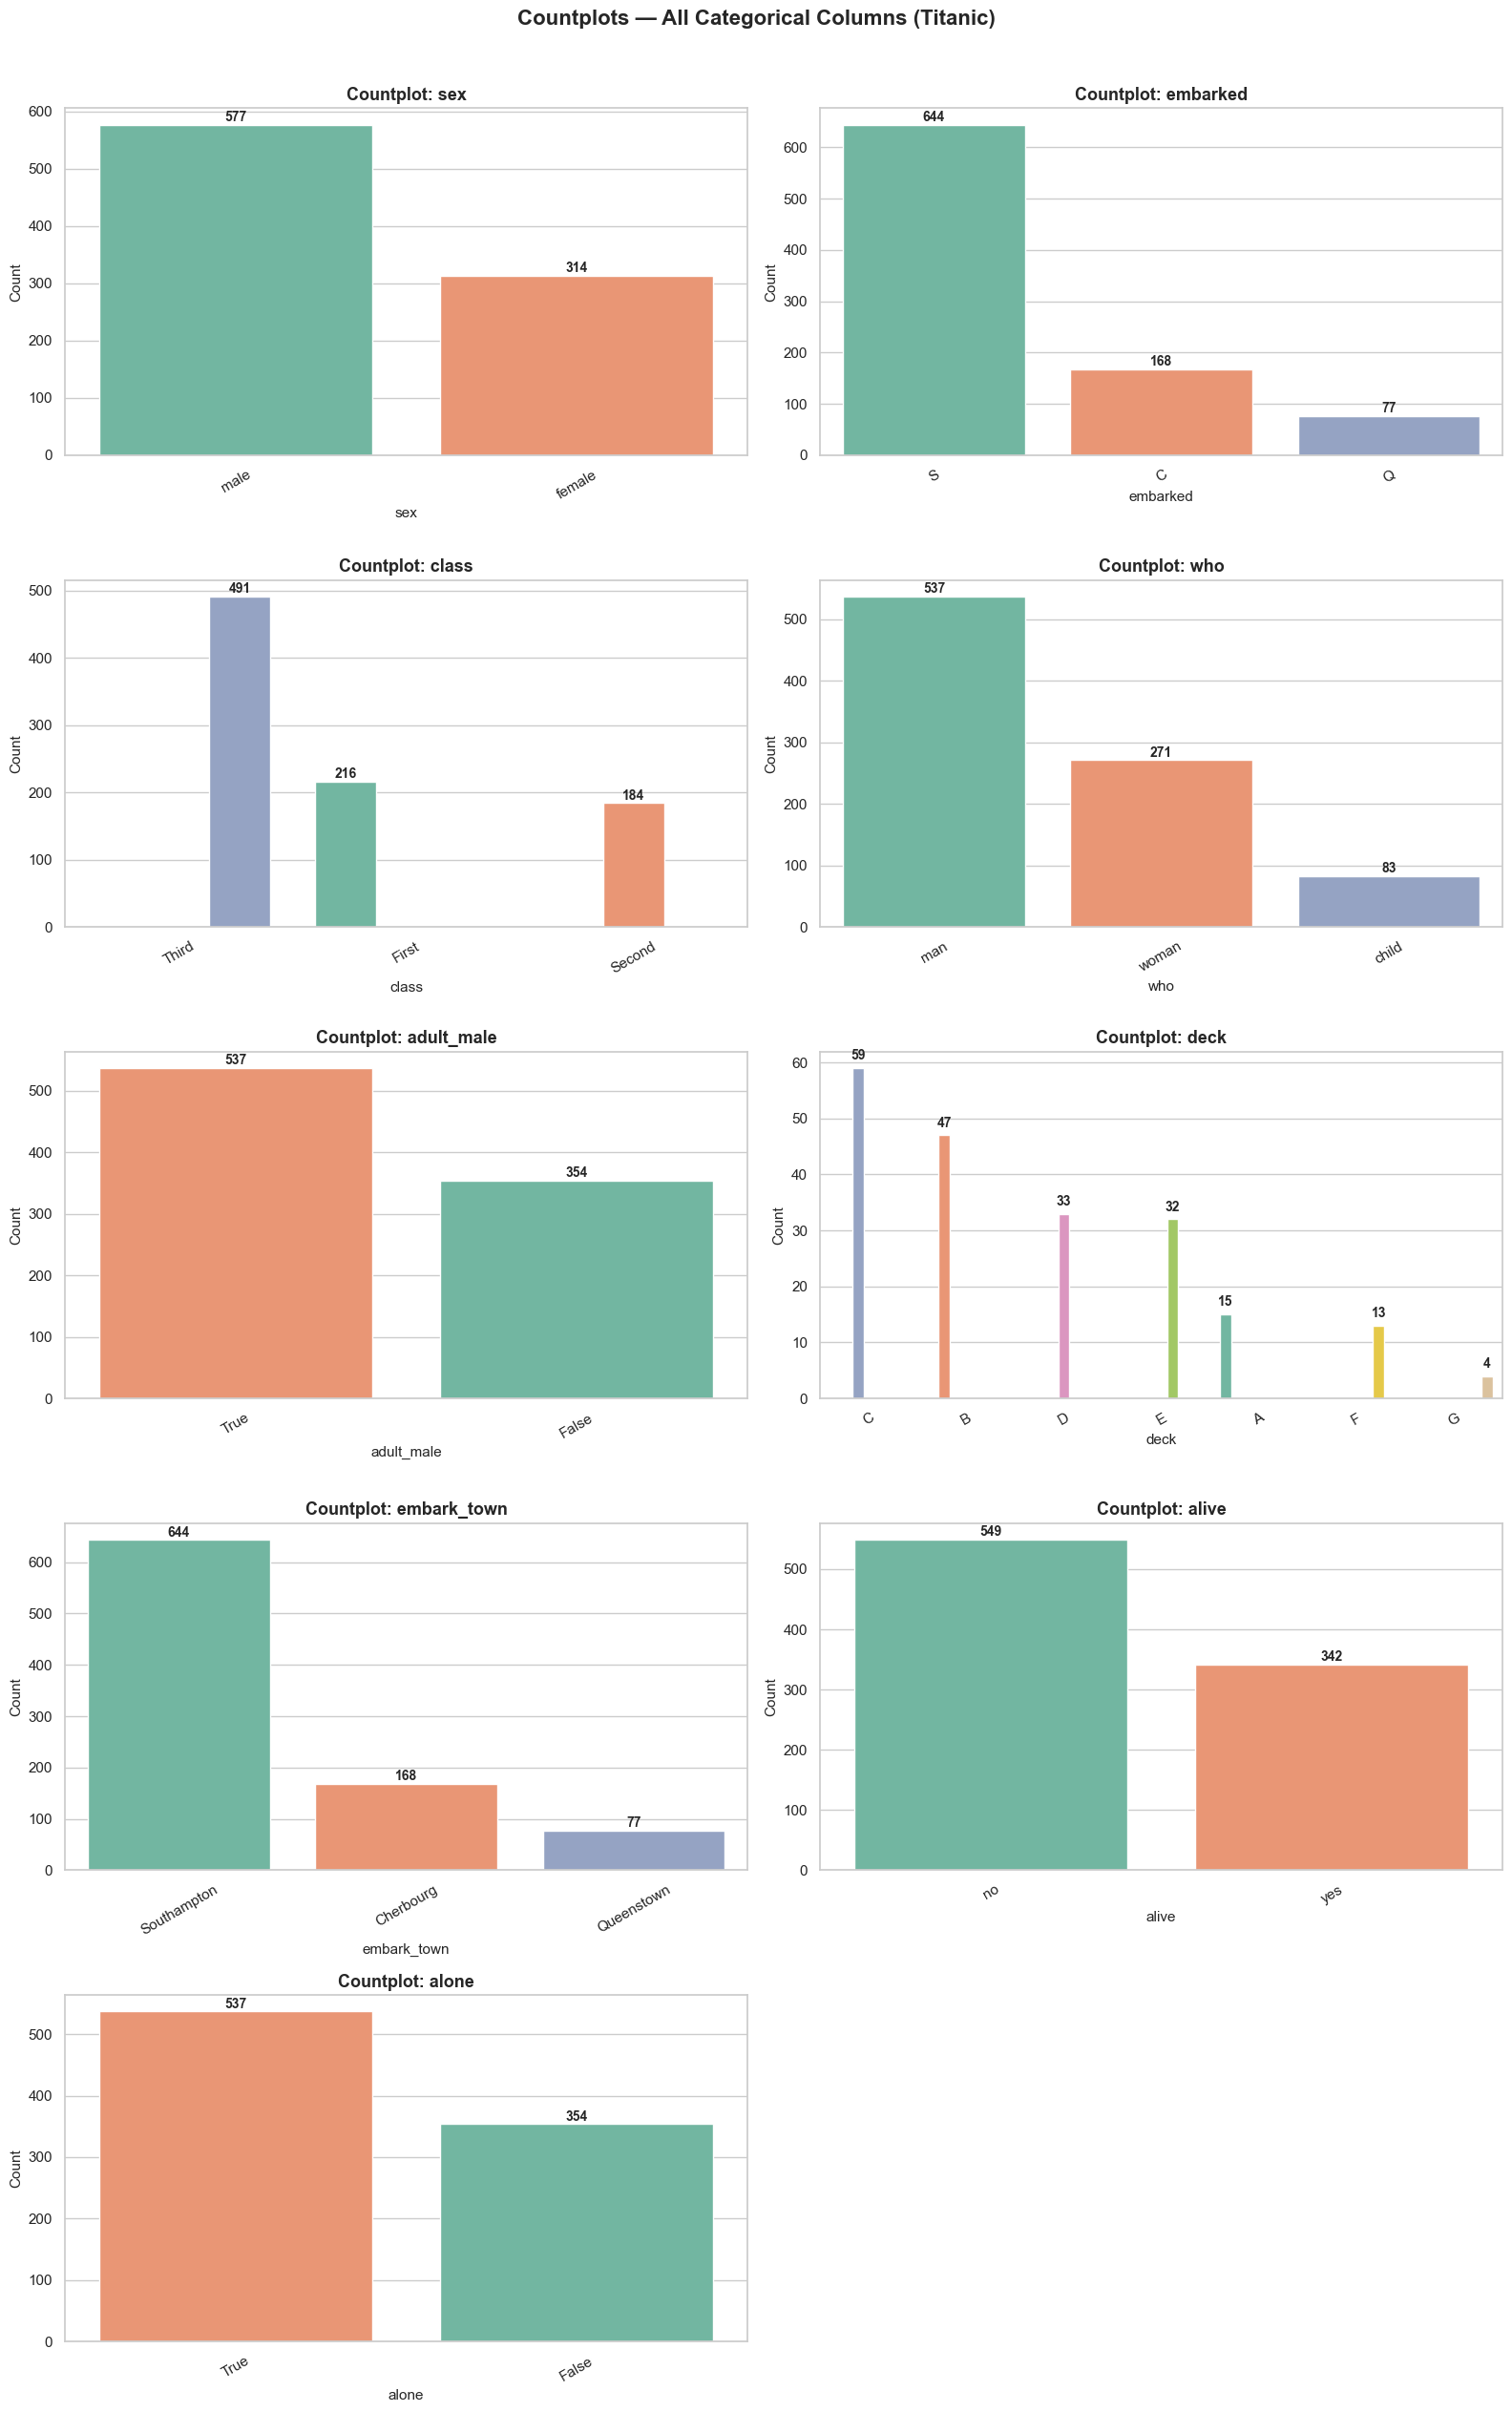

Saved: visual_report_output\05_countplots_categorical_columns.png


In [29]:

# PLOT 5: Countplot for each categorical column
# Shows how many times each category appears in the dataset

# Filter only useful categorical columns (skip high-cardinality ones)
cat_cols_filtered = [col for col in categorical_cols
                     if df[col].nunique() <= 10]  # max 10 unique values

print(f"Categorical columns for countplot: {cat_cols_filtered}")

n_cols_cat = 2
n_rows_cat = (len(cat_cols_filtered) + n_cols_cat - 1) // n_cols_cat

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(16, n_rows_cat * 5))
axes = axes.flatten()

colors = sns.color_palette("Set2", 10)  # nice color palette

for i, col in enumerate(cat_cols_filtered):
    value_counts = df[col].value_counts()

    sns.countplot(
        x=df[col],
        ax=axes[i],
        palette='Set2',
        order=value_counts.index,  # order by frequency
        hue=df[col],               # needed for newer seaborn versions
        legend=False
    )

    axes[i].set_title(f'Countplot: {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)

    # Annotate count on top of each bar
    for bar in axes[i].patches:
        height = int(bar.get_height())
        if height > 0:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                str(height),
                ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

# Hide extra axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Countplots — All Categorical Columns (Titanic)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

save_path = os.path.join(output_folder, '05_countplots_categorical_columns.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [30]:

# Final summary — list all saved PNG files
saved_files = sorted(os.listdir(output_folder))

print("=" * 55)
print("      VISUAL REPORT — COMPLETE SUMMARY")
print("=" * 55)
print(f"\nOutput Folder : '{output_folder}/'")
print(f"Dataset Used  : Titanic ({df.shape[0]} rows × {df.shape[1]} cols)")
print(f"\nSaved PNG Files ({len(saved_files)} total):")
for f in saved_files:
    print(f"     {f}")

print("\n" + "=" * 55)
print("All plots generated and saved successfully! ")
print("=" * 55)


      VISUAL REPORT — COMPLETE SUMMARY

Output Folder : 'visual_report_output/'
Dataset Used  : Titanic (891 rows × 15 cols)

Saved PNG Files (5 total):
     01_histograms_numeric_columns.png
     02_boxplots_outlier_detection.png
     03_heatmap_correlation_matrix.png
     04_pairplot_numeric_features.png
     05_countplots_categorical_columns.png

All plots generated and saved successfully! 
